In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# Set global plot style for clean presentation
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

print("✅ Libraries successfully imported.")

✅ Libraries successfully imported.


In [12]:
# 1. Input Reservoir Production History
data = {
    "Pressure_psi": [3200, 2920, 2710, 2520, 2360, 2230, 2120],
    "Gp_MMscf": [0, 8250, 18100, 29800, 42500, 56100, 70500],
    "Wp_STB": [0, 22000, 75000, 160000, 290000, 470000, 710000],
}
df = pd.DataFrame(data)

# Reservoir Constants
T_degF = 180  # Reservoir Temperature in °F
T_R = T_degF + 460  # Rankine conversion
B_w = 1.0  # Water formation volume factor (bbl/STB)


# Helper Functions for Fluid Properties
def calculate_z(P):
    """Simplified Z-factor correlation based on pressure"""
    return 1.0 - (0.00008 * P) + (0.000000015 * (P**2))


def calculate_bg(P, Z):
    """Gas Formation Volume Factor (Bg) in cu ft / scf"""
    return 0.02829 * (Z * T_R) / P


# Calculate PVT Data
df["Z"] = calculate_z(df["Pressure_psi"])
df["Bg"] = calculate_bg(df["Pressure_psi"], df["Z"])
df["P_over_Z"] = df["Pressure_psi"] / df["Z"]

# Display Initial Dataset
df[["Pressure_psi", "Gp_MMscf", "Wp_STB", "Z", "Bg", "P_over_Z"]]

,Pressure_psi,Gp_MMscf,Wp_STB,Z,Bg,P_over_Z
0,3200,0,0,0.897600,0.005079,3565.062389
1,2920,8250,22000,0.894296,0.005545,3265.138165
2,2710,18100,75000,0.893362,0.005969,3033.486444
3,2520,29800,160000,0.893656,0.006421,2819.877000
4,2360,42500,290000,0.894744,0.006864,2637.625958
5,2230,56100,470000,0.896193,0.007276,2488.301912
6,2120,70500,710000,0.897816,0.007668,2361.285609


--- METHOD 1 RESULTS ---
R-squared: 0.9485
Initial P/Z: 3410.05 psi
Apparent OGIP (G): 207621.11 MMscf


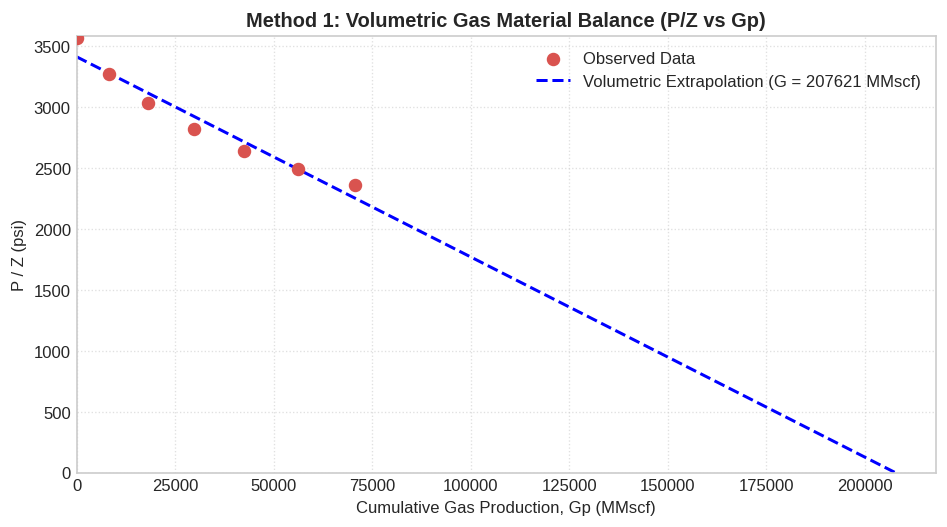

In [13]:
# Perform Linear Regression on P/Z vs Gp
slope_vol, intercept_vol, r_val, p_val, std_err = linregress(
    df["Gp_MMscf"], df["P_over_Z"]
)

# OGIP (G) is the x-intercept: G = -intercept / slope
G_volumetric = -intercept_vol / slope_vol

print(f"--- METHOD 1 RESULTS ---")
print(f"R-squared: {r_val**2:.4f}")
print(f"Initial P/Z: {intercept_vol:.2f} psi")
print(f"Apparent OGIP (G): {G_volumetric:.2f} MMscf")

# Plotting Method 1
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)
x_trend = np.array([0, G_volumetric])
y_trend = slope_vol * x_trend + intercept_vol

ax.scatter(
    df["Gp_MMscf"],
    df["P_over_Z"],
    color="#d9534f",
    s=50,
    zorder=5,
    label="Observed Data",
)
ax.plot(
    x_trend,
    y_trend,
    "b--",
    linewidth=1.8,
    label=f"Volumetric Extrapolation (G = {G_volumetric:.0f} MMscf)",
)

ax.set_title("Method 1: Volumetric Gas Material Balance (P/Z vs Gp)", fontsize=12, fontweight="bold")
ax.set_xlabel("Cumulative Gas Production, Gp (MMscf)")
ax.set_ylabel("P / Z (psi)")
ax.set_xlim(0, G_volumetric * 1.05)
ax.set_ylim(0, intercept_vol * 1.05)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

--- METHOD 2 RESULTS ---
True Water-Drive OGIP (G): 149173.40 MMscf


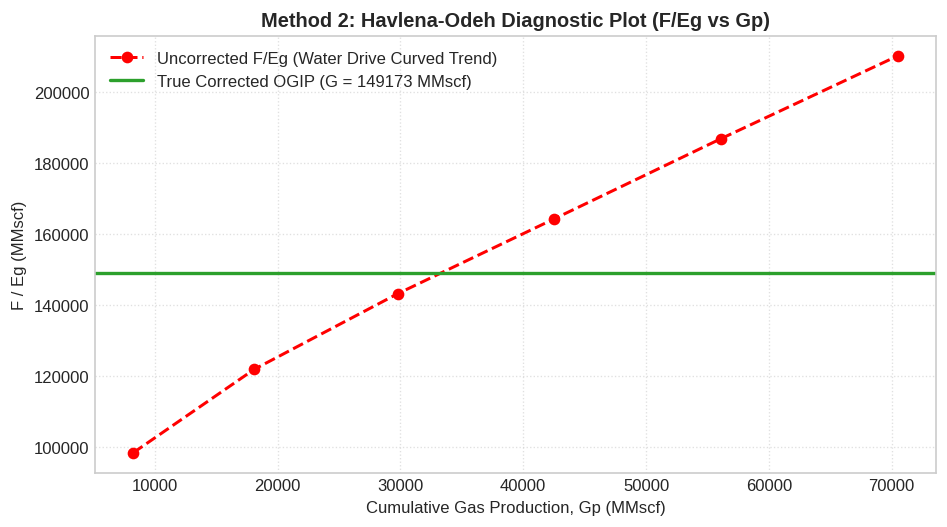

In [16]:
# Initial Conditions
Bgi = df["Bg"].iloc[0]

# Calculate Gas Expansion (Eg) and Total Underground Withdrawal (F)
df["Eg"] = df["Bg"] - Bgi  # cu ft / scf
df["F"] = (df["Gp_MMscf"] * 1e6 * df["Bg"]) + (
    df["Wp_STB"] * 5.615 * B_w
)  # cu ft

# Estimate Water Influx We (cu ft)
df["We_cuft"] = [0, 8e5, 2.8e6, 6.2e6, 1.1e7, 1.7e7, 1.7e7]

# Corrected OGIP: G = (F - We) / Eg
df["G_corrected_MMscf"] = ((df["F"] - df["We_cuft"]) / df["Eg"]) / 1e6

# True OGIP is the average of corrected points (excluding initial zero point)
G_water_drive = df["G_corrected_MMscf"].iloc[1:].mean()

print(f"--- METHOD 2 RESULTS ---")
print(f"True Water-Drive OGIP (G): {G_water_drive:.2f} MMscf")

# Plotting Method 2
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)
ax.plot(
    df["Gp_MMscf"].iloc[1:],
    (df["F"].iloc[1:] / df["Eg"].iloc[1:]) / 1e6,
    "ro--",
    linewidth=1.8,
    label="Uncorrected F/Eg (Water Drive Curved Trend)",
)
ax.axhline(
    y=G_water_drive,
    color="#2ca02c",
    linestyle="-",
    linewidth=2,
    label=f"True Corrected OGIP (G = {G_water_drive:.0f} MMscf)",
)

ax.set_title(
    "Method 2: Havlena-Odeh Diagnostic Plot (F/Eg vs Gp)",
    fontsize=12,
    fontweight="bold",
)
ax.set_xlabel("Cumulative Gas Production, Gp (MMscf)")
ax.set_ylabel("F / Eg (MMscf)")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

                      RESERVOIR ANALYSIS SUMMARY                          
 Volumetric Method OGIP (Apparent):       207621.11 MMscf
 Water-Drive Method OGIP (True):          149173.40 MMscf
 Reserve Overestimation Error:            +39.18%


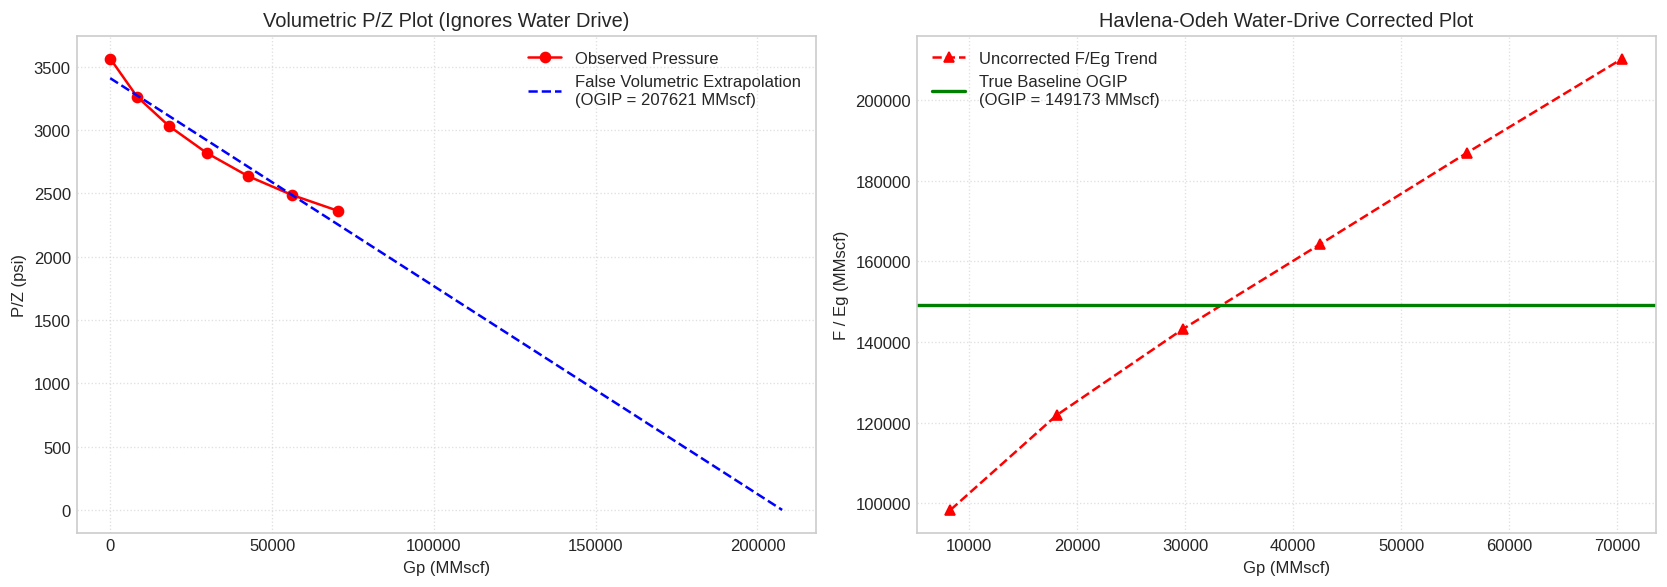

In [17]:
# Calculate Percentage Error
overestimation_pct = (
    (G_volumetric - G_water_drive) / G_water_drive
) * 100

print(
    f"=========================================================================="
)
print(f"                      RESERVOIR ANALYSIS SUMMARY                          ")
print(
    f"=========================================================================="
)
print(f" Volumetric Method OGIP (Apparent):       {G_volumetric:.2f} MMscf")
print(f" Water-Drive Method OGIP (True):          {G_water_drive:.2f} MMscf")
print(f" Reserve Overestimation Error:            +{overestimation_pct:.2f}%")
print(
    f"=========================================================================="
)

# Dual Plot Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Plot 1
ax1.plot(df["Gp_MMscf"], df["P_over_Z"], "ro-", label="Observed Pressure")
ax1.plot(
    x_trend,
    y_trend,
    "b--",
    label=f"False Volumetric Extrapolation\n(OGIP = {G_volumetric:.0f} MMscf)",
)
ax1.set_title("Volumetric P/Z Plot (Ignores Water Drive)")
ax1.set_xlabel("Gp (MMscf)")
ax1.set_ylabel("P/Z (psi)")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend()

# Plot 2
ax2.plot(
    df["Gp_MMscf"].iloc[1:],
    (df["F"].iloc[1:] / df["Eg"].iloc[1:]) / 1e6,
    "r^--",
    label="Uncorrected F/Eg Trend",
)
ax2.axhline(
    y=G_water_drive,
    color="g",
    linestyle="-",
    linewidth=2,
    label=f"True Baseline OGIP\n(OGIP = {G_water_drive:.0f} MMscf)",
)
ax2.set_title("Havlena-Odeh Water-Drive Corrected Plot")
ax2.set_xlabel("Gp (MMscf)")
ax2.set_ylabel("F / Eg (MMscf)")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()